## 필요 모듈 설치

In [5]:
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.2/526.2 kB 8.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
!pip install JPype1

In [1]:
!pip install pyahocorasick

In [7]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 13.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.9/444.9 kB 9.7 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 필요 라이브러리 호출

In [41]:
import pandas as pd
import numpy as np
import re #Regular Expression 특수문자, 반복 패턴 처리 용이
from collections import Counter
import os
import sys

#시각화
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import plotly.graph_objects as go  # Sankey Diagram

from konlpy.tag import Okt
'''
okt = Okt()
nouns = okt.nouns("맛있는 호박고구마 5kg 특가")
print(nouns) # 출력: ['호박고구마', '특가']
'''
plt.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='Malgun Gothic')

%matplotlib inline

# 작업 환경이 리눅스인지 윈도우인지 판별
import platform

if platform.system() == 'Linux':
    # 도커(리눅스) 환경 설정
    file_path = '/workspace/product_data_collection/refined_grocery_csv_for_classification/ML_grocery_data_sampled.csv'
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
else:
    # 윈도우 환경 설정
    file_path = r'C:\Users\LG\OneDrive\Desktop\REF_Classification_For_Ingredient_Recognition\product_data_collection\refined_grocery_csv_for_classification\ML_grocery_data_sampled.csv'
    font_path = 'C:/Windows/Fonts/malgun.ttf'

#경고 무시
import warnings
warnings.filterwarnings('ignore')

## 변수 설명

product_name: 1차 정제 제품명

category_large: 대분류 카테고리

category_medium: 중분류 카테고리

item_type: 제품의 카테고리 태그

grocery_item_name: 식재료 이름(타겟)

brand_name: 제품의 브랜드 명

## 데이터 전처리

In [42]:
grocery_df = pd.read_csv(file_path, encoding='utf-8')

print("Grocery data shape:", grocery_df.shape)

display(grocery_df.head(5))

grocery_df.info()

Grocery data shape: (1143, 6)


,product_name,category_large,category_medium,item_type,grocery_item_name,brand_name
0,[마이너피겨스] 유기농 오트음료,음료,주스,BEVERAGE,오트음료,마이너피겨스
1,[마이셰프] 찹스테이크,간편식,밀키트,RTC_MEAL,밀키트,마이셰프
2,[건강한우리집비옴] 생 아몬드 분말,조미료,가루분말,SAUCE_SEASONING,아몬드 분말,건강한우리집비옴
3,[김구원선생] 매일 마시는 국산 콩물,채소/곡물류,콩/두부,SIMPLE_PROCESSED,콩물,김구원선생
4,스코티시 리더 슈프림,술,기타 주류,ALCOHOL,위스키,스코티시


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   product_name       1143 non-null   object
 1   category_large     1143 non-null   object
 2   category_medium    1143 non-null   object
 3   item_type          1143 non-null   object
 4   grocery_item_name  1143 non-null   object
 5   brand_name         1143 non-null   object
dtypes: object(6)
memory usage: 53.7+ KB


### 제품명 정제 및 컬럼 생성 메서드

In [4]:
'''
from datetime import datetime
import json
# 파서 import
from product_name_parser import REFProductNameParser, create_brand_matcher

class REF_Grocery_Data_Cleaner_prototype:
        self.new_brands_added = set()
        self.update_parser()

    def update_parser(self):
        # 브랜드 매처 생성 로직을 사용 -> 브랜드 검색 사전 만들기
        self.matcher = create_brand_matcher(self.brand_dictionary)
        # 파서 클래스를 인스턴스
        self.parser = REFProductNameParser(brand_matcher=self.matcher)

    def refine_product_name(self, product_name: str):
        if not product_name or pd.isna(product_name):
            return product_name
        
        # 파서로 분석 수행 (브랜드 추출, 노이즈 제거 등)
        result = self.parser.parse(product_name)
        
        # 새로운 브랜드 발견 업데이트
        found_brand = result.brand_name
        if found_brand and found_brand not in self.brand_dictionary:
            self.brand_dictionary.add(found_brand)
            self.new_brands_added.add(found_brand)
            # 다음 행 처리에 즉시 반영
            self.update_parser()

        return result.refined_text

    def add_refined_column(self, df, input_col='product_name'):
        # cleaned_product_name 이라는 컬럼 생성
        print(f"[{input_col}] 컬럼 정제 및 브랜드 수집 중...")
        df['refined_product_name'] = df[input_col].apply(self.refine_product_name)
        return df

    def save_updated_dictionary(self, target_path):
        # 기존 브랜드 사전과 비교해 새로운 브랜드가 있을시 기존 브랜드 사전에 추가 및 데이터 저장
        if not self.new_brands_added:
            print("-" * 50)
            print("새로운 브랜드가 발견되지 않아 저장을 건너뜁니다.")
            print("-" * 50)
            return

        # 날짜 포맷팅
        date_str = datetime.now().strftime("%y_%m_%d")
        file_name = f"{date_str}_predict_grocery_dictionary.json"
        full_path = os.path.join(target_path, file_name)
        
        if not os.path.exists(target_path):
            os.makedirs(target_path)

        # 브랜드 사전을 정렬된 리스트(배열)로 변환하여 JSON 저장
        brand_list = sorted(list(self.brand_dictionary))
        with open(full_path, 'w', encoding='utf-8') as f:
            json.dump(brand_list, f, ensure_ascii=False, indent=4)
        
        print("-" * 50)
        print(f"신규 브랜드 {len(self.new_brands_added)}개 추가 발견.")
        print(f"JSON 사전 저장 완료: {full_path}")
        print("-" * 50)

# brand_name 컬럼의 유효한 값들을 중복 없애서 사전으로 만들기.
brand_dictionary = set(grocery_df['brand_name'].dropna().unique())

# 클리너 인스턴스 생성
cleaner = REF_Grocery_Data_Cleaner_prototype(brand_dictionary)

# 데이터 정제 및 새로운 컬럼 추가
# grocery_df에 직접 적용.
grocery_df = cleaner.add_refined_column(grocery_df, input_col='product_name')

# 결과 확인 (상위 5개 행)
print(grocery_df[['product_name', 'refined_product_name']].head())

# 지정된 경로에 JSON 사전 저장
TARGET_DIR = r"C:\Users\LG\OneDrive\Desktop\REF_Classification_For_Ingredient_Recognition\ML_dataset_smapled\grocery_classification_dataset\predict_brand_name" 
cleaner.save_updated_dictionary(TARGET_DIR)
'''

IndentationError: unindent does not match any outer indentation level (<string>, line 10)

술 제품들의 제품명이 잘림 -> 브랜드를 없애고 정제 제품명으로 바꾼 것이 문제.

In [43]:
from datetime import datetime
import json
# 파서 import
from product_name_parser import REFProductNameParser, create_brand_matcher

class REF_Grocery_Data_Cleaner:
    def __init__(self, brand_set: set):
        self.brand_dictionary = brand_set
        self.new_brands_added = set()
        self.update_parser()

    def update_parser(self):
        # 브랜드 매처 및 파서 초기화
        self.matcher = create_brand_matcher(self.brand_dictionary)
        self.parser = REFProductNameParser(brand_matcher=self.matcher)

    def refine_product_name(self, row, input_col='product_name', category_col='category_large'):
        product_name = row[input_col]
        category = str(row[category_col]).strip() if category_col in row else ""

        if not product_name or pd.isna(product_name):
            return product_name
        
        # 파서 실행 (브랜드 추출 및 괄호/특수문자 등 노이즈 제거)
        result = self.parser.parse(product_name)
        
        # 브랜드 사전 업데이트 (신규 브랜드 발견 시)
        # To-Do '단락 지우기'
        found_brand = result.brand_name
        if found_brand and found_brand not in self.brand_dictionary:
            self.brand_dictionary.add(found_brand)
            self.new_brands_added.add(found_brand)
            self.update_parser()

        # 술 카테고리 여부에 따른 분기 처리
        if category == '술':
            # 브랜드가 식별되었다면, 정제된 텍스트 앞에 브랜드를 다시 붙여줌
            # 파서가 정제 과정에서 브랜드를 삭제하더라도 여기서 복구됨
            refined = result.refined_text
            if found_brand and found_brand not in refined:
                return f"{found_brand} {refined}".strip()
            return refined
        else:
            # 술이 아닌 경우 기존 로직대로 정제된 텍스트(일반적으로 브랜드 제외) 반환
            return result.refined_text

    def add_refined_column(self, df, input_col='product_name', category_col='category_large'):
        print(f"[{input_col}] 정제 작업 시작 (대상: {len(df)}행)...")
        
        # 행(row) 전체를 전달하여 카테고리 값을 참조
        df['refined_product_name'] = df.apply(
            lambda row: self.refine_product_name(row, input_col, category_col), 
            axis=1
        )
        return df

    def save_updated_dictionary(self, target_path):
        if not self.new_brands_added:
            print("-" * 50)
            print("새로운 브랜드가 발견되지 않아 저장을 건너뜁니다.")
            print("-" * 50)
            return

        date_str = datetime.now().strftime("%y_%m_%d")
        file_name = f"{date_str}_predict_grocery_dictionary.json"
        full_path = os.path.join(target_path, file_name)
        
        if not os.path.exists(target_path):
            os.makedirs(target_path)

        brand_list = sorted(list(self.brand_dictionary))
        with open(full_path, 'w', encoding='utf-8') as f:
            json.dump(brand_list, f, ensure_ascii=False, indent=4)
        
        print("-" * 50)
        print(f"작업 완료: 신규 브랜드 {len(self.new_brands_added)}개 추가됨.")
        print(f"저장 경로: {full_path}")
        print("-" * 50)

In [44]:
brand_dictionary = set(grocery_df['brand_name'].dropna().unique())
ref_cleaner = REF_Grocery_Data_Cleaner(brand_dictionary)

# 데이터 정제
grocery_df = ref_cleaner.add_refined_column(grocery_df, input_col='product_name', category_col='category_large')

# 결과 확인
print(grocery_df[['category_large', 'product_name', 'refined_product_name']].head())

# JSON 사전 저장
TARGET_DIR = r"C:\Users\LG\OneDrive\Desktop\REF_Classification_For_Ingredient_Recognition\ML_dataset_smapled\grocery_classification_dataset\predict_brand_name"
ref_cleaner.save_updated_dictionary(TARGET_DIR)

display(grocery_df.info())

[product_name] 정제 작업 시작 (대상: 1143행)...
  category_large          product_name refined_product_name
0             음료     [마이너피겨스] 유기농 오트음료             유기농 오트음료
1            간편식          [마이셰프] 찹스테이크                찹스테이크
2            조미료   [건강한우리집비옴] 생 아몬드 분말             생 아몬드 분말
3         채소/곡물류  [김구원선생] 매일 마시는 국산 콩물         매일 마시는 국산 콩물
4              술           스코티시 리더 슈프림          스코티시 리더 슈프림
--------------------------------------------------
새로운 브랜드가 발견되지 않아 저장을 건너뜁니다.
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   product_name          1143 non-null   object
 1   category_large        1143 non-null   object
 2   category_medium       1143 non-null   object
 3   item_type             1143 non-null   object
 4   grocery_item_name     1143 non-null   object
 5   brand_name

None

In [45]:
condition = (grocery_df['refined_product_name'].str.len() <= 1) | (grocery_df['refined_product_name'].str.len() >= 200)
invalid_data = grocery_df[condition]

count = len(invalid_data)

if count > 0:
    print(f"(1자 이하 또는 200자 이상)에 해당하는 데이터가 {count}건 발견되었습니다.")
    print("-" * 50)
    # 발견된 데이터의 실제 내용 출력
    print(invalid_data['refined_product_name'])
    print("-" * 50)
else:
    print("모든 데이터가 정상 범위(2자 ~ 199자) 내에 있습니다.")

(1자 이하 또는 200자 이상)에 해당하는 데이터가 2건 발견되었습니다.
--------------------------------------------------
976     무
1004    꿀
Name: refined_product_name, dtype: object
--------------------------------------------------


## 데이터 시각화

### WordCloud 사용으로 product_name, refined_product_name 의 구성 단어 빈도 시각화

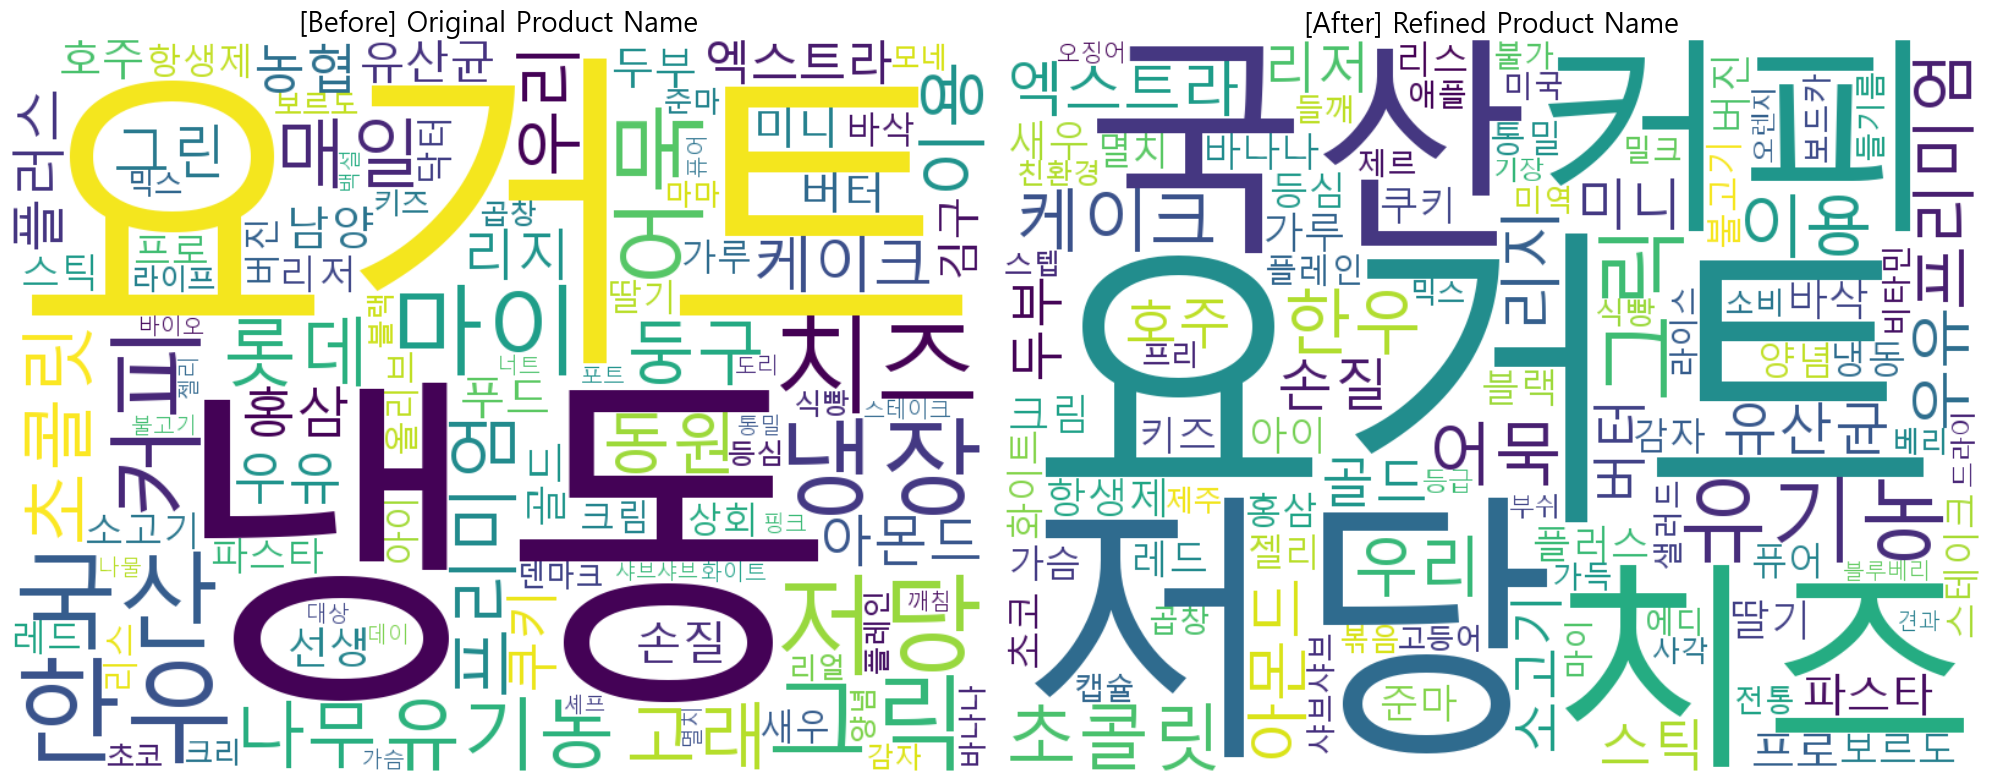


[비교 결과 상위 50개 단어]
원본(product_name)     | 정제후(refined_product_name)
-------------------------------------------------------
냉동(31)               | 요거트(30)
요거트(30)              | 저당(24)
한우(26)               | 국산(23)
저당(24)               | 치즈(22)
냉장(24)               | 커피(20)
국산(23)               | 유기농(18)
치즈(23)               | 그릭(18)
그릭(22)               | 초콜릿(17)
마이(20)               | 한우(16)
커피(20)               | 이용(15)
어묵(19)               | 케이크(15)
유기농(18)              | 어묵(15)
매일(17)               | 프리미엄(14)
롯데(17)               | 우리(14)
초콜릿(17)              | 아몬드(13)
나무(16)               | 리지(13)
프리미엄(16)             | 우유(13)
고래(16)               | 엑스트라(12)
둥구(15)               | 손질(11)
이용(15)               | 유산균(11)
동원(15)               | 호주(10)
우리(15)               | 골드(10)
케이크(15)              | 두부(10)
그린(14)               | 버터(10)
아몬드(13)              | 미니(10)
리지(13)               | 소고기(10)
우유(13)               | 스틱(10)
홍삼(13)               | 리저(10)
플러스(13)              | 파스

In [46]:
# 형태소 분석기 및 불용어 설정
okt = Okt()

# 식재료와 상관없는 빈출 불용어 리스트
stop_words = ['기획', '특가', '증정', '박스', '세트', '국내산', '내외', '중량', '입', '행사', '무료', '배송', '[26년 설]']

# 문장에서 명사만 추출하고 불용어를 제거하는 함수
def get_nouns_fast(text):
    if pd.isna(text): return ""
    # 명사 추출
    nouns = okt.nouns(str(text))
    # 한 글자 단어 제거 및 불용어 제거
    return [n for n in nouns if len(n) > 1 and n not in stop_words]

# 원본 제품명에서 명사 추출
grocery_df['nouns_original'] = grocery_df['product_name'].apply(get_nouns_fast)

# 정제된 제품명에서 명사 추출
grocery_df['nouns_refined'] = grocery_df['refined_product_name'].apply(get_nouns_fast)

# 리스트를 풀어서 전체 빈도 계산
all_nouns_product_name = [word for nouns in grocery_df['nouns_original'] for word in nouns]
all_nouns_refined_product_name = [word for nouns in grocery_df['nouns_refined'] for word in nouns]

counts_product_name = Counter(all_nouns_product_name)
counts_refined_product_name = Counter(all_nouns_refined_product_name)

# 워드 클라우드 생성 함수
def draw_wordcloud(word_counts, title, ax):
    wc = WordCloud(
        font_path=font_path,
        background_color='white',
        width=800,
        height=600,
        max_words=100
    ).generate_from_frequencies(word_counts)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=20)
    ax.axis('off')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 왼쪽: 원본 데이터 워드클라우드
draw_wordcloud(counts_product_name, "[Before] Original Product Name", axes[0])

# 오른쪽: 정제 후(refined) 워드클라우드 [명칭 변경]
draw_wordcloud(counts_refined_product_name, "[After] Refined Product Name", axes[1])

plt.tight_layout()
plt.show()

# 상위 단어 수치 비교 출력
print("\n[비교 결과 상위 50개 단어]")
print(f"{'원본(product_name)':<20} | {'정제후(refined_product_name)':<20}")
print("-" * 55)
for (w1, c1), (w2, c2) in zip(counts_product_name.most_common(50), counts_refined_product_name.most_common(50)):
    print(f"{w1}({c1}):<20".split(':')[0].ljust(20) + " | " + f"{w2}({c2})")

1. 브랜드를 제거하지 않은 제품명 데이터에선 메일, 롯데, 남양 같은 브랜드들이 상위권을 차지함. 브랜드를 제거한 제품명에선 식재료 명이 더욱 많아졌음
   koNLPy 를 사용해 형용사나 부사같은 불필요한 수식어를 제거함으로서 추후 있을 모델학습의 효율을 늘릴 수 있을 것이라고 생각함.
   
2. 리지, 리저, 준마 등 (오/리지/날, 리저/브, 준마/이 다이긴죠 추정) 이런 식으로 과절단 되는 현상이 있는 것으로 보임. 이런 현상이 있을 시에 모델 학습에 많은 악영향을
   칠 것으로 보이기도 함.
   -> 불용어 처리(브랜드도 껴있는 것 같아서 별로 좋지 못할듯), 주류 특화 사전(공공 데이터 or 주류 데이터 api 찾아보기)을 만들어 오리지날, 리저브, 준마이 다이긴죠 등        으로 분석하도록 koNLPy 파인 튜닝

3. 요거트, 치즈, 커피, 한우 등 데이터가 몰려있는 경우가 많음. -> 데이터 어그멘테이션이 필수조건으로 보임. 


### WordCloud 사용해 grocery_item_name 의 중복도 시각화

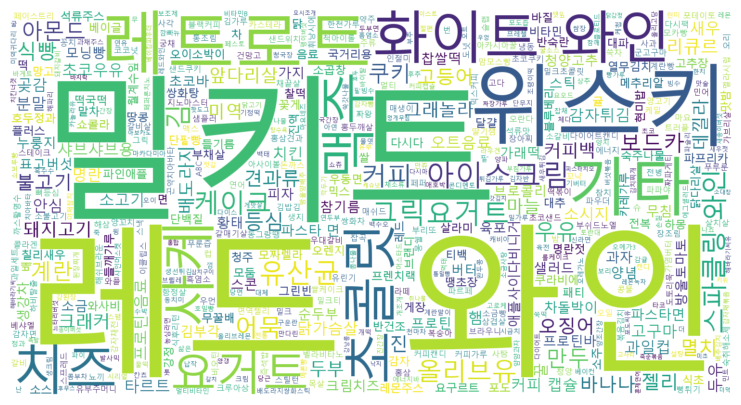

--------------------------------------------------------------------------------------------------------------
레드 와인(50)          | 밀키트(46)            | 위스키(42)            | 레트로트(24)           | 기타(19)            
화이트 와인(17)         | 사케(16)             | 맥주(16)             | 아이스크림(15)          | 초콜릿(15)           
요거트(14)            | 그릭요거트(14)          | 김(13)              | 유산균(13)            | 스파클링 와인(12)       
케이크(12)            | 올리브유(11)           | 쿠키(8)              | 보드카(8)             | 치즈(8)             
어묵(7)              | 계란(7)              | 등심(7)              | 진(6)               | 멸치(6)             
바나나(6)             | 우유(6)              | 식빵(6)              | 고등어(6)             | 만두(5)             
커피(5)              | 리큐르(5)             | 앞다리살(5)            | 데낄라(5)             | 견과류(5)            
크래커(5)             | 그래놀라(5)            | 커피백(5)             | 불고기(5)             | 오트음료(4)           
프로틴 음료(4)          | 명란(4)              | 과일컵(4)             | 감자

In [47]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

grocery_combined_text = " ".join(grocery_df['grocery_item_name']) # 워드 클라우드는 하나의 긴 텍스트를 받으니 조인으로 묶기

wordcloud = WordCloud(
    font_path=font_path,
    width=1500, 
    height=800,
    background_color='white',
    colormap='viridis',    # 색상 테마 설정
    max_words=1143        # 최대 표시 단어 수
).generate(grocery_combined_text)

# 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 축 숨기기
plt.show()

grocery_item_name_counts = grocery_df['grocery_item_name'].value_counts().head(1143)

print("-" * 110)
items = [f"{item}({count})" for item, count in grocery_item_name_counts.items()]

num_cols = 5  # 한 줄에 5개씩 출력
for i in range(0, len(items), num_cols):
    row = items[i : i + num_cols]
    # 각 항목을 20자 너비로 왼쪽 정렬하여 열을 맞춤
    print(" | ".join(f"{item:<18}" for item in row))
print("-" * 110)

1. 식재료 전부를 찍어봤을 때 밀키트, 레드 와인, 화이트 와인, 레트로트, 위스키 등 주류 또는 간편식에 데이터가 치중되어있음.
   -> 어그멘테이션이 필수임, 주류는 제품 이름 안에 브랜드가 포함된 경우가 대부분임. 이를 통해 주류 필터 사전을 통해 주류는 ML을 거치지않고 필터링 사전을 통해
      분류하는 것도 좋은 선택일 듯함.
   
2. 사람들이 많이 소비하는 채소류나, 식품의 데이터가 적음. 추후에 따로 채워야할 것.

3. 레드 와인, 레드와인 이름이 같게 만들어야함. -> 코드로 띄어쓰기를 다 없애서 분석을 진행, 추후엔 어떻게 할지 생각해보기.

### Sankey Diagram 시각화

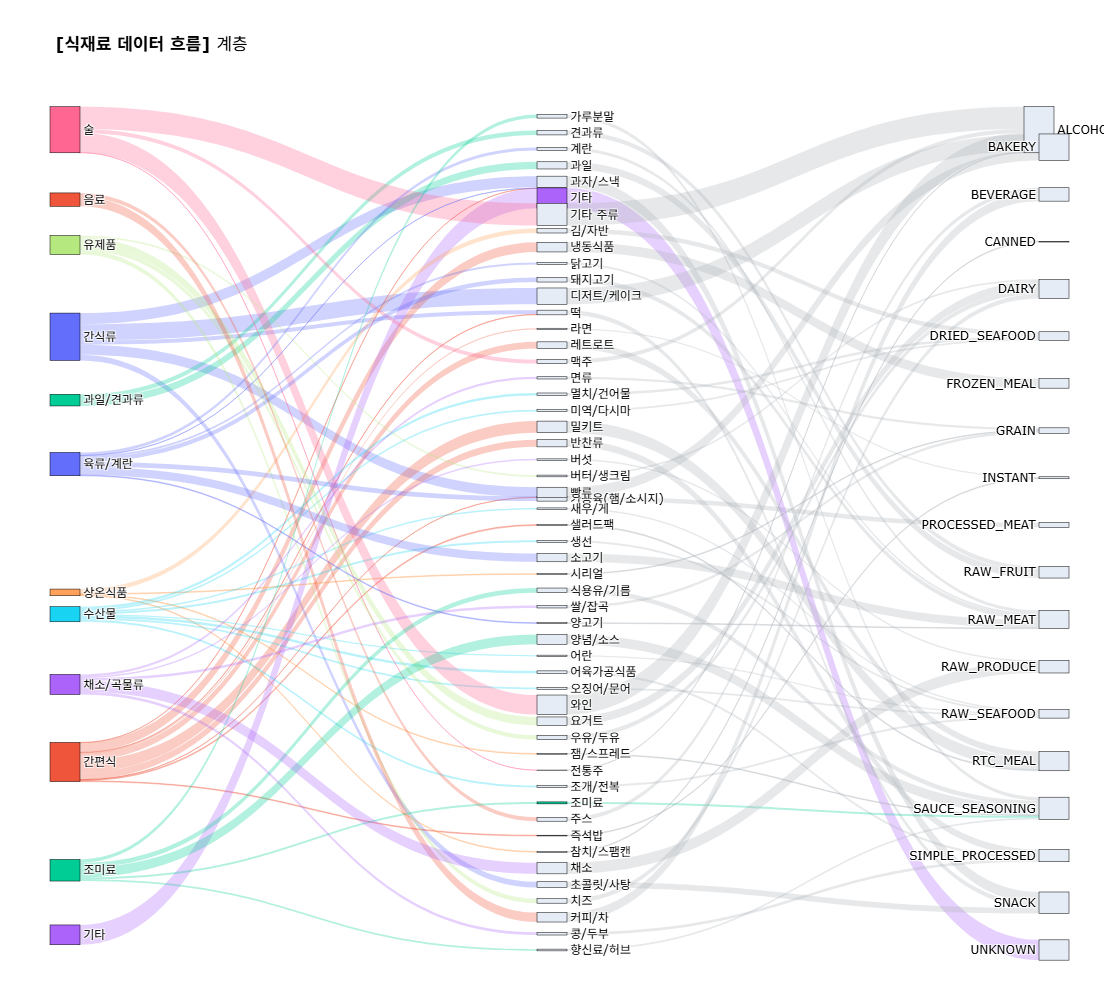

In [48]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 데이터 흐름 정의 (수직적 위계만 추출)
# 단계 1: 대분류 -> 중분류
l_flow1 = grocery_df.groupby(['category_large', 'category_medium']).size().reset_index(name='v')
# 단계 2: 중분류 -> 아이템 타입
l_flow2 = grocery_df.groupby(['category_medium', 'item_type']).size().reset_index(name='v')

# 노드 이름 고유화 및 인덱싱 (중복 방지를 위해 공백 개수를 다르게 설정)
# 대분류: 이름 + " " (공백 1개)
# 중분류: 이름 + "  " (공백 2개)
# 아이템: 이름 (공백 없음)
unique_l_large = [n + " " for n in sorted(grocery_df['category_large'].unique())]
unique_l_medium = [n + "  " for n in sorted(grocery_df['category_medium'].unique())]
unique_center = sorted(grocery_df['item_type'].unique())

all_nodes = unique_l_large + unique_l_medium + unique_center
node_map = {n: i for i, n in enumerate(all_nodes)}

# 링크 데이터 생성 (이름 겹침 방지 맵핑)
links = []

# 대분류(공백1) -> 중분류(공백2)
for _, r in l_flow1.iterrows():
    links.append({
        's': node_map[r['category_large'] + " "], 
        't': node_map[r['category_medium'] + "  "], 
        'v': r['v']
    })

# 중분류(공백2) -> 아이템 타입(공백0)
for _, r in l_flow2.iterrows():
    links.append({
        's': node_map[r['category_medium'] + "  "], 
        't': node_map[r['item_type']], 
        'v': r['v']
    })

links_df = pd.DataFrame(links)

# 색상 설정
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692', '#B6E880']
large_cat_list = sorted(grocery_df['category_large'].unique())
color_map = {cat: colors[i % len(colors)] for i, cat in enumerate(large_cat_list)}

node_colors = []
for n in all_nodes:
    clean_n = n.strip()
    if clean_n in color_map:
        node_colors.append(color_map[clean_n])
    else:
        node_colors.append("#E5ECF6")

link_colors = []
for _, row in links_df.iterrows():
    src_node = all_nodes[row['s']].strip()
    base_color = color_map.get(src_node, "#ABB2B9")
    r, g, b = tuple(int(base_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    link_colors.append(f"rgba({r}, {g}, {b}, 0.3)")

# 좌표 설정 (직사각형 형태 유지)
x_pos = [0.0]*len(unique_l_large) + [0.5]*len(unique_l_medium) + [1.0]*len(unique_center)

def get_y(n_list):
    if len(n_list) <= 1: return [0.5]
    return [i / (len(n_list) - 1) for i in range(len(n_list))]

y_pos = get_y(unique_l_large) + get_y(unique_l_medium) + get_y(unique_center)

# 시각화
fig = go.Figure(data=[go.Sankey(
    arrangement = "fixed", # 직사각형 고정
    node = dict(
        pad = 20,
        thickness = 30,
        label = [n.strip() for n in all_nodes],
        x = x_pos,
        y = y_pos,
        color = node_colors,
        line = dict(color = "black", width = 0.5)
    ),
    link = dict(
        source = links_df['s'],
        target = links_df['t'],
        value = links_df['v'],
        color = link_colors
    )
)])

fig.update_layout(
    title_text="<b>[식재료 데이터 흐름]</b> 계층 ",
    font=dict(size=12, color="black"),
    width=1600,
    height=1000,
    margin=dict(l=50, r=50, t=100, b=50),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

1. 대분류 데이터에 불균형 존재함. 간식류(191), 술(186), 기타(80) 카테고리가 전체 흐름의 큰 비중을 차지. 반면, 상온식품(27)이나 과일/견과류(47)는 상대적으로 비중이     너무 적음.

2. 중분류에서도 디저트/케이크(66), 밀키트(47) 등 특정 품목에 데이터가 쏠려 있어, 모델이 빈도가 낮은 품목을 학습할 때 어려움을 겪을 수 있다고 생각.

3. 기타에 대한 취급. 기타를 어떻게 취급할까 생각해봤는데 이 데이터셋에서 결측치로 취급해도 되지않을까 싶음. 모델이 이 노이즈를 학습한다면 득이되는 것은 없을 듯.

4. 간편식에서 빵류가 보임. 이는 데이터 프레임 제작과정중 실수가 있었음을 시사함.
   -> 대분류-중분류-아이템 타입 계층 구조를 활용해 데이터 프레임의 계층 구조가 잘 되었는지 검증 후 수정.


### 대분류 - 기타 삭제

In [8]:
# 삭제 전 데이터 개수 확인
original_count = len(grocery_df)

# category_large가 기타인 행 제외시키고 재정렬
grocery_df = grocery_df[grocery_df['category_large'] != '기타'].reset_index(drop=True)

# 삭제 결과 확인
dropped_count = original_count - len(grocery_df)
print(f"삭제된 기타 카테고리 행: {dropped_count}개")
print(f"남은 유효 데이터 개수: {len(grocery_df)}개")
print(f"현재 데이터 shape: {grocery_df.shape}")

# 실제로 잘 제거되었는지 고유값 확인
print("\n대분류 리스트")
print(grocery_df['category_large'].unique())

삭제된 기타 카테고리 행: 80개
남은 유효 데이터 개수: 1063개
현재 데이터 shape: (1063, 7)

대분류 리스트
['음료' '간편식' '조미료' '채소/곡물류' '술' '육류/계란' '수산물' '유제품' '간식류' '상온식품' '과일/견과류']


### 대분류-중분류-아이템 타입의 관계가 정합한지 정합성 검증 및 수정

In [16]:
# 계층 데이터 정의
hierarchy_data = {
    "술": {"items": [{"name": "와인", "item_type": "ALCOHOL"}, {"name": "전통주", "item_type": "ALCOHOL"}, {"name": "맥주", "item_type": "ALCOHOL"}, {"name": "소주", "item_type": "ALCOHOL"}, {"name": "기타 주류", "item_type": "ALCOHOL"}]},
    "채소/곡물류": {"items": [{"name": "채소", "item_type": "RAW_PRODUCE"}, {"name": "버섯", "item_type": "RAW_PRODUCE"}, {"name": "쌀/잡곡", "item_type": "GRAIN"}, {"name": "콩/두부", "item_type": "SIMPLE_PROCESSED"}, {"name": "면류", "item_type": "GRAIN"}]},
    "육류/계란": {"items": [{"name": "소고기", "item_type": "RAW_MEAT"}, {"name": "돼지고기", "item_type": "RAW_MEAT"}, {"name": "닭고기", "item_type": "RAW_MEAT"}, {"name": "오리고기", "item_type": "RAW_MEAT"}, {"name": "양고기", "item_type": "RAW_MEAT"}, {"name": "계란", "item_type": "RAW_MEAT"}, {"name": "가공육(햄/소시지)", "item_type": "PROCESSED_MEAT"}]},
    "수산물": {"items": [{"name": "생선", "item_type": "RAW_SEAFOOD"}, {"name": "조개/전복", "item_type": "RAW_SEAFOOD"}, {"name": "새우/게", "item_type": "RAW_SEAFOOD"}, {"name": "멸치/건어물", "item_type": "DRIED_SEAFOOD"}, {"name": "오징어/문어", "item_type": "RAW_SEAFOOD"}, {"name": "미역/다시마", "item_type": "DRIED_SEAFOOD"}, {"name": "어육가공식품", "item_type": "SIMPLE_PROCESSED"}, {"name": "어란", "item_type": "RAW_SEAFOOD"}]},
    "과일/견과류": {"items": [{"name": "과일", "item_type": "RAW_FRUIT"}, {"name": "견과류", "item_type": "RAW_FRUIT"}, {"name": "냉동과일", "item_type": "SIMPLE_PROCESSED"}]},
    "간편식": {"items": [{"name": "밀키트", "item_type": "RTC_MEAL"}, {"name": "레트로트", "item_type": "RTC_MEAL"}, {"name": "즉석밥", "item_type": "INSTANT"}, {"name": "라면", "item_type": "INSTANT"}, {"name": "냉동식품", "item_type": "FROZEN_MEAL"}, {"name": "샐러드팩", "item_type": "RTC_MEAL"}, {"name": "반찬류", "item_type": "SIMPLE_PROCESSED"}]},
    "조미료": {"items": [{"name": "식용유/기름", "item_type": "SAUCE_SEASONING"}, {"name": "양념/소스", "item_type": "SAUCE_SEASONING"}, {"name": "조미료", "item_type": "SAUCE_SEASONING"}, {"name": "가루분말", "item_type": "SAUCE_SEASONING"}, {"name": "향신료/허브", "item_type": "SAUCE_SEASONING"}]},
    "음료": {"items": [{"name": "탄산음료", "item_type": "BEVERAGE"}, {"name": "이온음료", "item_type": "BEVERAGE"}, {"name": "주스", "item_type": "BEVERAGE"}, {"name": "커피/차", "item_type": "BEVERAGE"}, {"name": "생수", "item_type": "BEVERAGE"}]},
    "유제품": {"items": [{"name": "우유/두유", "item_type": "DAIRY"}, {"name": "요거트", "item_type": "DAIRY"}, {"name": "치즈", "item_type": "DAIRY"}, {"name": "버터/생크림", "item_type": "DAIRY"}]},
    "간식류": {"items": [{"name": "빵류", "item_type": "BAKERY"}, {"name": "디저트/케이크", "item_type": "BAKERY"}, {"name": "과자/스낵", "item_type": "SNACK"}, {"name": "초콜릿/사탕", "item_type": "SNACK"}, {"name": "떡", "item_type": "SNACK"}]},
    "상온식품": {"items": [{"name": "참치/스팸캔", "item_type": "CANNED"}, {"name": "김/자반", "item_type": "DRIED_SEAFOOD"}, {"name": "잼/스프레드", "item_type": "SAUCE_SEASONING"}, {"name": "시리얼", "item_type": "GRAIN"}]}
}

# 클래스 외부에서 매핑 진행
# 중분류를 Key로 하여 대분류와 타입을 즉시 조회
master_rule_map = {}

for category_large, content in hierarchy_data.items():
    for item in content['items']:
        master_rule_map[item['name']] = {
            'valid_large': category_large,
            'valid_item_type': item['item_type']
        }

print(f"총 {len(master_rule_map)}개의 중분류 규칙 매핑 완료.")

총 58개의 중분류 규칙 매핑 완료.


In [17]:
# master_rule_map을 기준으로 데이터 정합성을 검증하고 동기화하는 클래스
class REF_grocery_data_synchronizer:
    
    def __init__(self, target_df, rule_map):
        self.working_df = target_df.copy()
        self.rules = rule_map
        self.initial_count = len(target_df)
        self.error_count = 0
        
    # 결측치 및 기타 대분류 제거
    def purge_invalid_data(self):
        before = len(self.working_df)
        
        # 결측치 및 대분류 기타 제거
        self.working_df = self.working_df.dropna(subset=['category_large', 'category_medium', 'item_type'])
        self.working_df = self.working_df[self.working_df['category_large'] != '기타'].reset_index(drop=True)
        
        print(f" 불필요 데이터 정리 완료: {before - len(self.working_df)}개 삭제")
        return self

    # 정합성 검증
    def sync_with_master_rules(self):
        
        def process_row(row):
            category_large = row['category_large']
            category_medium = row['category_medium']
            item_type = row['item_type']
            
            # 중분류가 계층 데이터에 존재할 경우
            if category_medium in self.rules:
                correct_data = self.rules[category_medium]
                
                # 내부적으로 오류 여부 판단 (에러 카운트용)
                is_error = (category_large != correct_data['valid_large'] or \
                            item_type != correct_data['valid_item_type'])
                
                if is_error:
                    self.error_count += 1
                
                # 값은 무조건 계층 데이터 기준으로 수정
                return pd.Series([correct_data['valid_large'], category_medium, correct_data['valid_item_type']])
            
            # 계층 데이터에 없는 중분류인 경우 원본 유지 및 에러 처리
            self.error_count += 1
            return pd.Series([category_large, category_medium, item_type])

        # 데이터 업데이트
        self.working_df[['category_large', 'category_medium', 'item_type']] = \
            self.working_df.apply(process_row, axis=1)
        
        print(f"정합성 검증 완료: {self.error_count}개 수정 및 동기화 완료")
        return self

    # 데이터 품질 리포트 출력
    def report_quality_metrics(self):
        total = len(self.working_df)
        error_rate = (self.error_count / total * 100) if total > 0 else 0
        print("\n" + "="*50)
        print(f" 품질: 전체 {total}건 중 오류 {self.error_count}건 (오류율: {error_rate:.2f}%)")
        print("="*50 + "\n")
        return self

    # 최종 데이터 반환
    def get_final_df(self):
        return self.working_df

In [18]:
synchronizer = REF_grocery_data_synchronizer(grocery_df, master_rule_map)

grocery_df = (synchronizer
    .purge_invalid_data()           # 결측치 및 기타 제거
    .sync_with_master_rules()        # 내부 동기화 및 수리
    .report_quality_metrics()       # 리포트 출력
    .get_final_df())                # 최종 데이터 반환 (3개 컬럼)

# 결과 확인
display(grocery_df.head())

 불필요 데이터 정리 완료: 80개 삭제
정합성 검증 완료: 5개 수정 및 동기화 완료

 품질: 전체 1063건 중 오류 5건 (오류율: 0.47%)



,product_name,category_large,category_medium,item_type,grocery_item_name,brand_name,refined_product_name
0,[마이너피겨스] 유기농 오트음료,음료,주스,BEVERAGE,오트음료,마이너피겨스,유기농 오트음료
1,[마이셰프] 찹스테이크,간편식,밀키트,RTC_MEAL,밀키트,마이셰프,찹스테이크
2,[건강한우리집비옴] 생 아몬드 분말,조미료,가루분말,SAUCE_SEASONING,아몬드 분말,건강한우리집비옴,생 아몬드 분말
3,[김구원선생] 매일 마시는 국산 콩물,채소/곡물류,콩/두부,SIMPLE_PROCESSED,콩물,김구원선생,매일 마시는 국산 콩물
4,스코티시 리더 슈프림,술,기타 주류,ALCOHOL,위스키,스코티시,스코티시 리더 슈프림


=========================================================================================================================================================
1. 계층 구조가 잘못 매핑된 데이터의 개수가 5개가 있었음. -> 생키 다이어그램으로 확인 후, 클래스 생성
   이것으로 데이터 검증용 클래스가 생겼으니 추후 데이터 검증에 유리할 수 있음. 

2. 현재 데이터는 카테고리 계층 구조를 잘 반영하고 있음을 시사함.

3. 데이터의 양도 중요하지만 질도 굉장히 중요하니 대분류-기타 와 같은 결측치들을 삭제하는 것은 ML 모델 학습에 좋은 영향을 줄 수 있을듯.

### 제품명, 정제 제품명 글자수 히스토그램 시각화

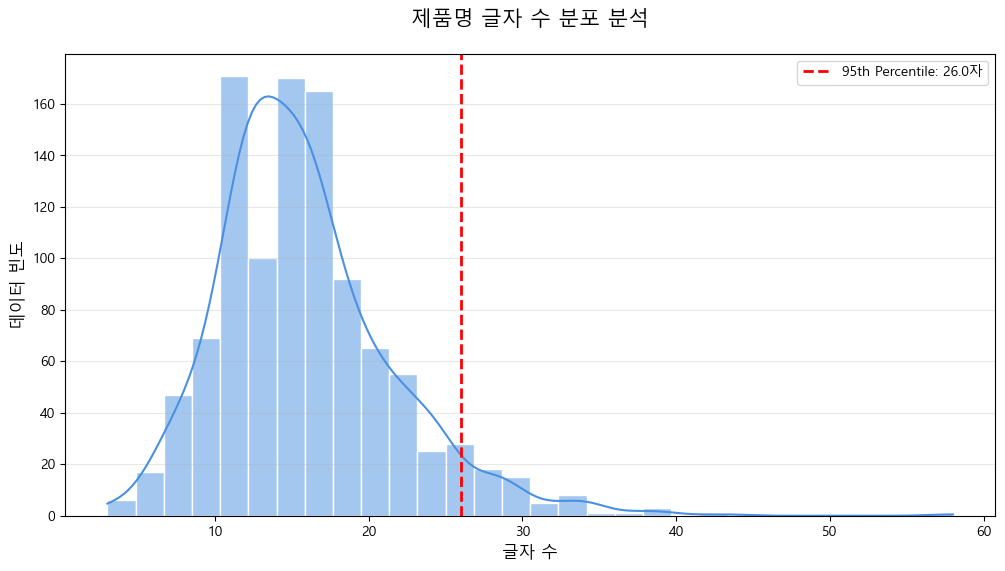

최대 길이: 58자
95% 지점: 26.0자
99% 지점: 34.0자

BERT max_seq_length 설정값: 39


In [21]:
# 제품명 글자 수 계산후 히스토그램 시각화 및 max_len 설정 함수
def REF_visualize_length_distribution(dataframe, column_name='product_name'):
    # 글자 수 계산
    dataframe['text_length'] = dataframe[column_name].astype(str).apply(len)
    
    # 통계치 산출
    max_val = dataframe['text_length'].max()
    percentile_95 = dataframe['text_length'].quantile(0.95)
    percentile_99 = dataframe['text_length'].quantile(0.99)
    
    # 시각화 설정
    plt.figure(figsize=(12, 6))
    sns.histplot(dataframe['text_length'], bins=30, kde=True, color='#4A90E2', edgecolor='white')
    
    # 95% 지점에 수직선 표시
    plt.axvline(percentile_95, color='red', linestyle='--', linewidth=2, 
                label=f'95th Percentile: {percentile_95:.1f}자')
    
    # 그래프 제목 및 라벨 설정
    plt.title('제품명 글자 수 분포 분석', fontsize=15, pad=20)
    plt.xlabel('글자 수', fontsize=12)
    plt.ylabel('데이터 빈도', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # 그래프 출력
    plt.show()
    
    # 수치 리포트 출력
    print(f"최대 길이: {max_val}자")
    print(f"95% 지점: {percentile_95}자")
    print(f"99% 지점: {percentile_99}자")
    
    # 토큰화 버퍼를 고려한 권장값
    recommended_max_len = int(np.ceil(percentile_95 * 1.5))
    print(f"\nBERT max_seq_length 설정값: {recommended_max_len}")
    
    return recommended_max_len

# 파이프라인 실행
recommended_len = REF_visualize_length_distribution(grocery_df)

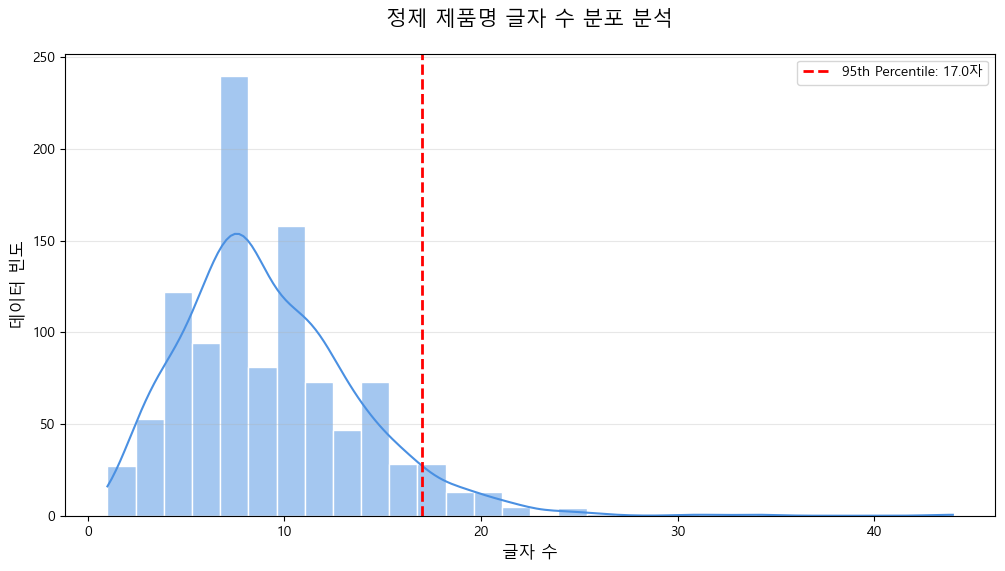

최대 길이: 44자
95% 지점: 17.0자
99% 지점: 22.0자

BERT max_seq_length 설정값: 26


In [20]:
# 제품명 글자 수 계산후 히스토그램 시각화 및 max_len 설정 함수
def REF_visualize_length_distribution(dataframe, column_name='refined_product_name'):
    # 글자 수 계산
    dataframe['text_length'] = dataframe[column_name].astype(str).apply(len)
    
    # 통계치 산출
    max_val = dataframe['text_length'].max()
    percentile_95 = dataframe['text_length'].quantile(0.95)
    percentile_99 = dataframe['text_length'].quantile(0.99)
    
    # 시각화 설정
    plt.figure(figsize=(12, 6))
    sns.histplot(dataframe['text_length'], bins=30, kde=True, color='#4A90E2', edgecolor='white')
    
    # 95% 지점에 수직선 표시
    plt.axvline(percentile_95, color='red', linestyle='--', linewidth=2, 
                label=f'95th Percentile: {percentile_95:.1f}자')
    
    # 그래프 제목 및 라벨 설정
    plt.title('정제 제품명 글자 수 분포 분석', fontsize=15, pad=20)
    plt.xlabel('글자 수', fontsize=12)
    plt.ylabel('데이터 빈도', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # 그래프 출력
    plt.show()
    
    # 수치 리포트 출력
    print(f"최대 길이: {max_val}자")
    print(f"95% 지점: {percentile_95}자")
    print(f"99% 지점: {percentile_99}자")
    
    # 토큰화 버퍼를 고려한 권장값
    recommended_max_len = int(np.ceil(percentile_95 * 1.5))
    print(f"\nBERT max_seq_length 설정값: {recommended_max_len}")
    
    return recommended_max_len

# 파이프라인 실행
recommended_len = REF_visualize_length_distribution(grocery_df)

1. 정제 제품

### 제품명 내 식재료 키워드 포함 개수를 분석하고 시각화

In [25]:
# 제품명 내 식재료 키워드 포함 개수를 분석하고 시각화하는 클래스
class REF_Grocery_Ingredient_Density_Visualizer:
    
    # 데이터와 키워드 리스트를 초기화하는 메서드
    def __init__(self, target_df, product_text_col='refined_product_name', ingredient_label_col='grocery_item_name'):
        
        # 백엔드 규격 유지를 위해 원본 데이터프레임을 복사하여 사용
        self.working_df = target_df.copy()
        self.product_text_col = product_text_col
        self.ingredient_label_col = ingredient_label_col
        
        # 중복 없는 전체 식재료 키워드 목록 추출
        self.master_ingredient_list = self.working_df[self.ingredient_label_col].dropna().unique().tolist()
        self.density_distribution = None

    # 단일 제품명에 포함된 식재료 키워드 개수를 카운트하는 메서드
    def count_matches(self, product_name):
        
        product_name = str(product_name)
        
        # 마스터 리스트의 각 키워드가 제품명에 포함되어 있는지 확인
        return sum(1 for ingredient in self.master_ingredient_list if str(ingredient) in product_name)

    # 매칭 개수를 계산하고 범주형 분포를 산출하는 메서드
    def compute_stats(self):
        
        # 원본 데이터프레임에 컬럼을 추가하지 않고 로컬 변수로 계산
        match_counts = self.working_df[self.product_text_col].apply(self.count_matches)
        
        # 개수별 범주화 로직 정의
        def categorize(count):
            if count == 0: return '0개'
            elif count == 1: return '1개'
            elif count == 2: return '2개'
            else: return '3개 이상'
        
        density_categories = match_counts.apply(categorize)
        
        # 분석 결과의 비율 계산 및 저장
        category_order = ['0개', '1개', '2개', '3개 이상']
        self.density_distribution = density_categories.value_counts(normalize=True).reindex(category_order).fillna(0) * 100

    # 분석된 밀도 비중을 막대그래프로 시각화하는 메서드
    def render_chart(self):
        # 디버깅
        if self.density_distribution is None:
            print("[Error] compute_stats 메서드를 먼저 실행하십시오.")
            return
            
        plt.figure(figsize=(12, 6))
        # 파이프라인 설계도 테마에 맞춘 색상 구성
        bar_colors = ['#F59E0B', '#4A90E2', '#7C3AED', '#10B981'] 
        
        ax = sns.barplot(x=self.density_distribution.index, y=self.density_distribution.values, palette=bar_colors)

        # 각 막대 상단에 백분율 표시
        for bar in ax.patches:
            ax.annotate(f'{bar.get_height():.1f}%', 
                        (bar.get_x() + bar.get_width() / 2., bar.get_height()), 
                        ha='center', va='center', fontsize=12, xytext=(0, 9), 
                        textcoords='offset points', fontweight='bold')

        plt.title('정제 제품명 내 식재료 정보 밀도 분석', fontsize=16, pad=20)
        plt.ylabel('데이터 비중 (%)', fontsize=12)
        plt.xlabel('식재료 포함 개수', fontsize=12)
        plt.ylim(0, max(self.density_distribution.values) + 15)
        plt.grid(axis='y', alpha=0.2)
        plt.show()

        print(f"분석 대상 데이터: {len(self.working_df)}건")

    # 식재료 키워드가 탐지되지 않은 제품명 샘플을 출력하는 메서드
    def show_unmatched_samples(self, top_n=10):
        
        # 내부 함수를 통해 실시간으로 필터링하여 반환
        unmatched_mask = self.working_df[self.product_text_col].apply(self.count_matches) == 0
        return self.working_df[unmatched_mask][[self.product_text_col]].head(top_n)

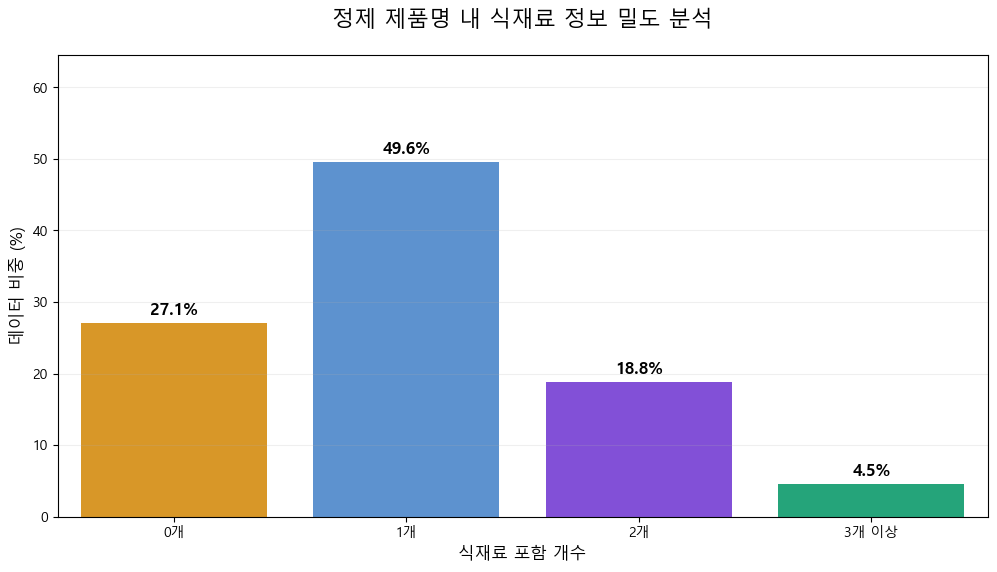

분석 대상 데이터: 1063건


,refined_product_name
1,찹스테이크
5,스프링 시드 비올라 쉬라즈
13,포스파티딜세린
16,하우스 블렌드 드립백
18,카라쿠치 골드
19,미니스 디스펜서 나폴리타너
23,케이준 후라이
25,글렌카담 15년
27,프레스코발디 테누타 카스틸리오니 토스카나
28,1865 마스터 블랜드


In [26]:
visualizer = REF_Grocery_Ingredient_Density_Visualizer(grocery_df)
visualizer.compute_stats()
visualizer.render_chart()

# 미탐지 데이터 확인
display(visualizer.show_unmatched_samples())

========================================================================================================================================================
1. 제품명 내에 식재료 키워드가 0개인 비율이 높은 것은 술, 밀키트, 레트르트 비율이 전체 데이터 중 많은 비율을 차지하고 있기 때문에(생키 다이어그램 중 밀키트, 주류, 레     트 로트의 비율이 높았음) 27.1% 나 차지하는 것 같다고 생각.

2. 1개인 비율이 49.6% -> Cosine Similarity 를 이용해 식재료 사전과 비교하면 효율이 좋을 것 같음.

3. 23.3% 가 2개 이상을 포함하는 제품명들인데 이들을 분류해내기 위해선 파이프 라인에서 대분류-중분류-카테고리태그를 동시에 학습하는 Multi-task 구조를 택한게 아주 좋은    선택 같음.

4. 데이터의 글자수 시각화를 보면 알다시피 최대 글자수 기준 99% 인 글자수가 22자임. 대부분은 15 글자 이하(띄어쓰기 포함). 이중에 식재료가 2개씩 들어간 데이터들이 존재     함. 이는 문맥이해의 중요성을 보여주고, KoNLPy 를 사용할시(파이프 라인 내에 존재) 파인튜닝이 필요함을 보여줌.

In [39]:
class REF_Category_Unmatched_Analyzer:
    # 데이터와 식재료 키워드 목록을 초기화하는 메서드
    def __init__(self, target_df, product_text_col='refined_product_name', 
                 large_cat_col='category_large', medium_cat_col='category_medium',
                 ingredient_label_col='grocery_item_name'):
        
        # 원본 데이터 스키마 보호를 위해 복사본 생성
        self.working_df = target_df.copy()
        self.product_text_col = product_text_col
        self.large_cat_col = large_cat_col
        self.medium_cat_col = medium_cat_col
        
        # 고유 식재료 키워드 목록 추출
        self.master_keywords = self.working_df[ingredient_label_col].dropna().unique().tolist()
        self.distribution_stats = None

    # 제품명에 포함된 식재료 키워드 개수를 계산하는 메서드
    def count_keyword_matches(self, product_name):
        product_name = str(product_name)
        # 키워드 사전을 순회하며 포함 여부 합산
        return sum(1 for keyword in self.master_keywords if str(keyword) in product_name)

    # 전체 데이터와 미탐지 그룹에서의 특정 카테고리 비중을 산출하는 메서드
    def analyze_category_proportions(self):
        # 로컬 변수를 사용하여 미탐지(0개 매칭) 마스크 생성
        match_results = self.working_df[self.product_text_col].apply(self.count_keyword_matches)
        zero_match_mask = (match_results == 0)
        
        total_size = len(self.working_df)
        zero_match_df = self.working_df[zero_match_mask]
        zero_match_size = len(zero_match_df)
        
        # 분석 대상 타겟 설정
        target_list = [
            ('술', self.large_cat_col, '술 (대분류)'),
            ('밀키트', self.medium_cat_col, '밀키트 (중분류)'),
            ('레트로트', self.medium_cat_col, '레트로트 (중분류)')
        ]
        
        proportions = []
        for val, col, label in target_list:
            # 전체 데이터셋 기준 비율 계산
            overall_pct = (self.working_df[col] == val).sum() / total_size * 100
            proportions.append({'항목': label, '그룹': '전체 데이터', '비율': overall_pct})
            
            # 미탐지(27.1%) 그룹 기준 비율 계산
            if zero_match_size > 0:
                unmatched_pct = (zero_match_df[col] == val).sum() / zero_match_size * 100
            else:
                unmatched_pct = 0
            proportions.append({'항목': label, '그룹': '미탐지 데이터 (27.1%)', '비율': unmatched_pct})
            
        self.distribution_stats = pd.DataFrame(proportions)

    # 전체와 미탐지 그룹의 비중을 두 개의 차트로 시각화하는 메서드
    def render_comparison_charts(self):
        if self.distribution_stats is None:
            print("[Report] analyze_category_proportions 메서드를 먼저 실행하십시오.")
            return

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # 왼쪽 차트: 전체 데이터 내 비중
        overall_data = self.distribution_stats[self.distribution_stats['그룹'] == '전체 데이터']
        sns.barplot(data=overall_data, x='항목', y='비율', ax=axes[0], palette='Blues_d')
        axes[0].set_title('전체 데이터 내 주요 카테고리 점유율', fontsize=14, pad=15)
        axes[0].set_ylabel('비율 (%)')
        axes[0].set_xlabel('')

        for bar in axes[0].patches:
            axes[0].annotate(f'{bar.get_height():.1f}%', (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                             ha='center', va='center', fontsize=11, xytext=(0, 8), textcoords='offset points', fontweight='bold')

        # 오른쪽 차트: 미탐지 그룹 내 비중
        unmatched_data = self.distribution_stats[self.distribution_stats['그룹'] == '미탐지 데이터 (27.1%)']
        sns.barplot(data=unmatched_data, x='항목', y='비율', ax=axes[1], palette='Oranges_d')
        axes[1].set_title('미탐지 데이터(27.1%) 내 주요 카테고리 점유율', fontsize=14, pad=15)
        axes[1].set_ylabel('비율 (%)')
        axes[1].set_xlabel('')

        for bar in axes[1].patches:
            axes[1].annotate(f'{bar.get_height():.1f}%', (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                             ha='center', va='center', fontsize=11, xytext=(0, 8), textcoords='offset points', fontweight='bold')

        plt.tight_layout()
        plt.show()

        print("데이터 그룹 간 카테고리 비중 비교 분석을 완료")

    # 미탐지된 제품명 중 특정 카테고리에 속하는 샘플을 확인하는 메서드
    def show_unmatched_samples(self, target_val, target_col, limit=10):
        # 실시간 필터링을 통해 원본 컬럼 생성 방지
        zero_match_mask = self.working_df[self.product_text_col].apply(self.count_keyword_matches) == 0
        category_mask = (self.working_df[target_col] == target_val)
        return self.working_df[zero_match_mask & category_mask][[self.product_text_col]].head(limit)

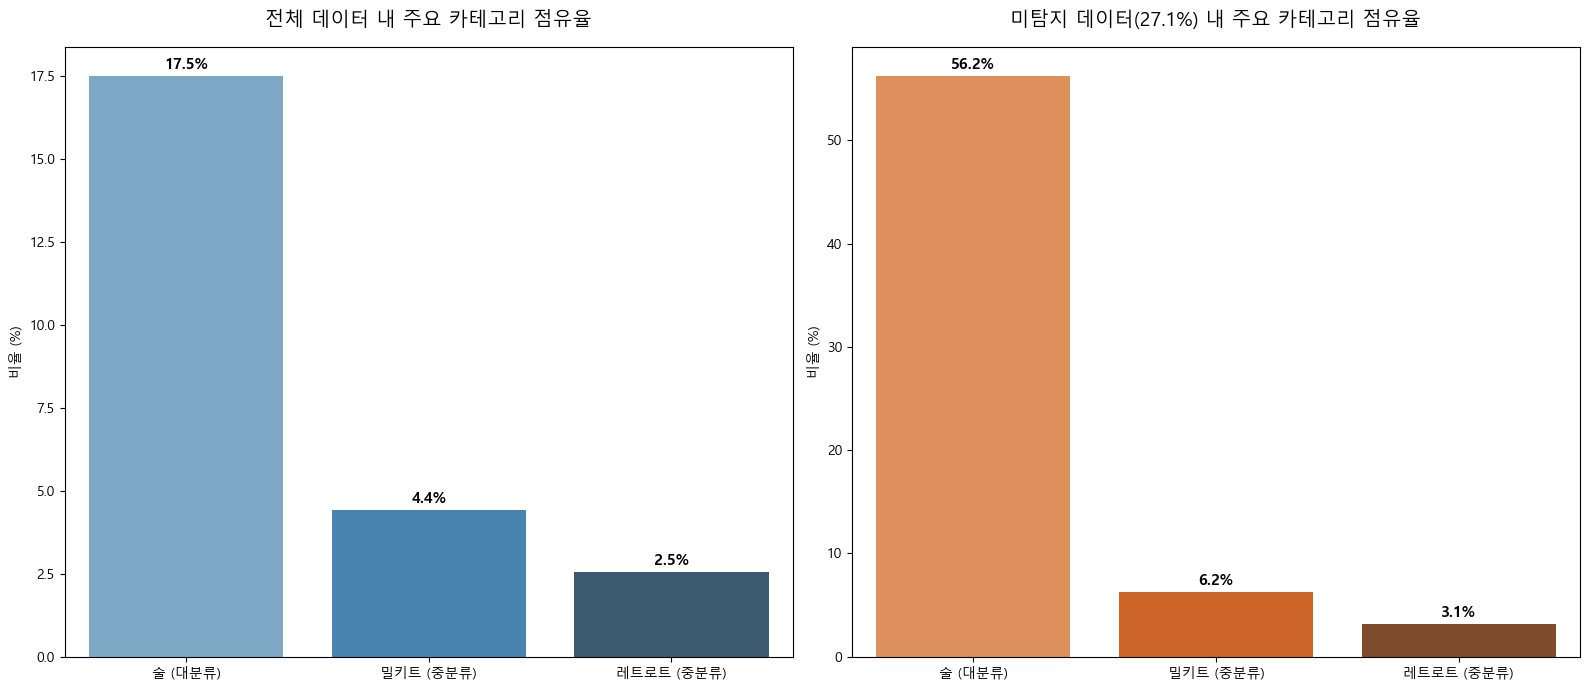

데이터 그룹 간 카테고리 비중 비교 분석을 완료


,refined_product_name
5,스프링 시드 비올라 쉬라즈
18,카라쿠치 골드
25,글렌카담 15년
27,프레스코발디 테누타 카스틸리오니 토스카나
28,1865 마스터 블랜드
30,비네티 델 살렌토 졸라 네그로 아마로
36,글렌 모렌지 18년 디 인피니타
41,스톨리치나야 솔티드 카라멜
49,클라로스쿠로 그란 말벡
51,판티니 에디찌오네


In [40]:
analyzer = REF_Category_Unmatched_Analyzer(grocery_df)
analyzer.analyze_category_proportions()
analyzer.render_comparison_charts()

# 미탐지된 '술' 데이터의 실제 제품명 확인
display(analyzer.show_unmatched_samples('술', 'category_large'))